# Introduction
Artificial intelligence and machine learning are now commonly used in healthcare, particularly to support tasks such as disease screening, diagnosis, and risk prediction (stratification). These technologies can analyse large datasets far more quickly than a human clinician, which is especially valuable in healthcare systems already under significant pressure. In practice, this can help clinicians identify patterns that might otherwise be missed and support faster decision-making.

However, the use of AI in medical settings raises ethical concerns. Decisions made or influenced by algorithms raise important ethical questions, particularly around accountability, transparency, and patient trust. As AI systems become more embedded in clinical workflows, these issues become increasingly difficult to ignore.

A significant ethical challenge associated with medical AI is bias. Machine learning models are trained using historical data, and if that data contains inequalities or imbalances, the resulting models may reproduce those patterns. In a health care setting, this can lead to unequal performance across protected characteristics, such as error rates between gender, age and ethnicity. These disparities can contribute towards a higher rate of false negatives for certain populations, potentially delaying diagnosis and treatment. 



In [1]:
import datetime
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


I0000 00:00:1776254288.902583 2338583 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data_frame = pd.read_csv('../data/thyroid_cancer_risk_data.csv')

data_frame.head()
data_frame.shape
print(data_frame.dtypes.to_frame("dtype"))

                       dtype
Patient_ID             int64
Age                    int64
Gender                   str
Country                  str
Ethnicity                str
Family_History           str
Radiation_Exposure       str
Iodine_Deficiency        str
Smoking                  str
Obesity                  str
Diabetes                 str
TSH_Level            float64
T3_Level             float64
T4_Level             float64
Nodule_Size          float64
Thyroid_Cancer_Risk      str
Diagnosis                str


In [3]:
missing_count = data_frame.isna().sum()
print("Missing values per column:")
print(missing_count)

duplicates = data_frame.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Missing values per column:
Patient_ID             0
Age                    0
Gender                 0
Country                0
Ethnicity              0
Family_History         0
Radiation_Exposure     0
Iodine_Deficiency      0
Smoking                0
Obesity                0
Diabetes               0
TSH_Level              0
T3_Level               0
T4_Level               0
Nodule_Size            0
Thyroid_Cancer_Risk    0
Diagnosis              0
dtype: int64
Number of duplicate rows: 0


In [4]:
# TUNABLE VARS
AGE_GROUPS = {
    "AGE_1": {"min": 0, "max": 29, "label": "0-29"},
    "AGE_2": {"min": 30, "max": 39, "label": "30-39"},
    "AGE_3": {"min": 40, "max": 49, "label": "40-49"},
    "AGE_4": {"min": 50, "max": 59, "label": "50-59"},
    "AGE_5": {"min": 60, "max": 69, "label": "60-69"},
    "AGE_6": {"min": 70, "max": 120, "label": "70+"},
}


In [5]:
# CONSTANTS
AGE_COL = "Age"
ETHNICITY_COL = "Ethnicity"
GENDER_COL = "Gender"
TARGET_COL = "Diagnosis"
POSITIVE_CLASS = "Malignant"

In [6]:
df_copy = data_frame.copy()

df_copy = df_copy.drop(columns=["Patient_ID"])

# clean text cols
for column_name in df_copy.select_dtypes(include="object").columns:
    df_copy[column_name] = df_copy[column_name].str.strip().str.lower()

# binary target
df_copy["target"] = df_copy[TARGET_COL].map({
    "benign": 0,
    "malignant": 1
})

print("Target distribution:")
print(df_copy["target"].value_counts())
print("\nTarget proportions:")
print(df_copy["target"].value_counts(normalize=True))

Target distribution:
target
0    163196
1     49495
Name: count, dtype: int64

Target proportions:
target
0    0.767292
1    0.232708
Name: proportion, dtype: float64


/tmp/ipykernel_2338583/1219164775.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column_name in df_copy.select_dtypes(include="object").columns:


In [7]:
# Helper functions
def assign_age_group(age_value, age_groups):
    for group_key, group_info in age_groups.items():
        if group_info["min"] <= age_value <= group_info["max"]:
            return group_info["label"]
    return "unknown"

In [8]:
# create age group col

df_copy["Age_Group"] = df_copy[AGE_COL].apply(
    assign_age_group,
    age_groups=AGE_GROUPS
)

print("Age group distribution:")
print(df_copy["Age_Group"].value_counts().sort_index())

Age group distribution:
Age_Group
0-29     42657
30-39    28506
40-49    28361
50-59    28494
60-69    28055
70+      56618
Name: count, dtype: int64


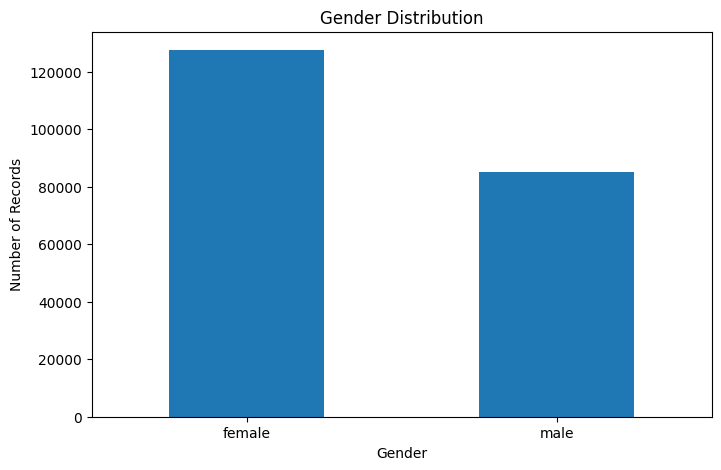

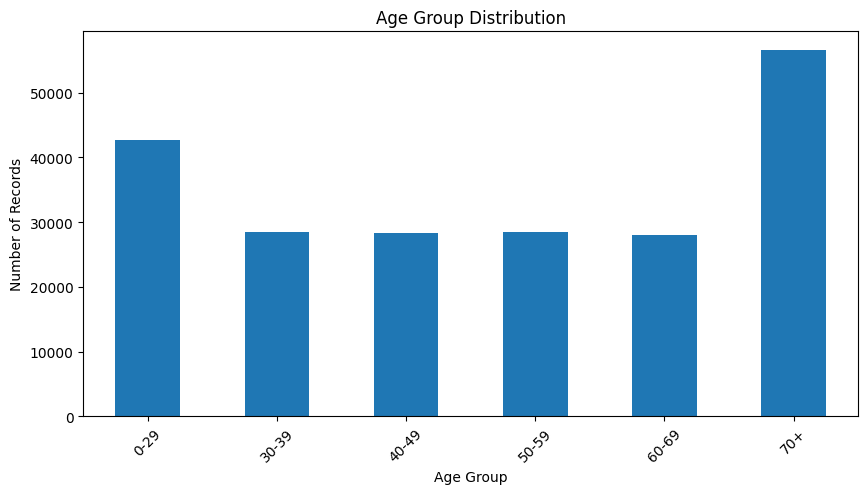

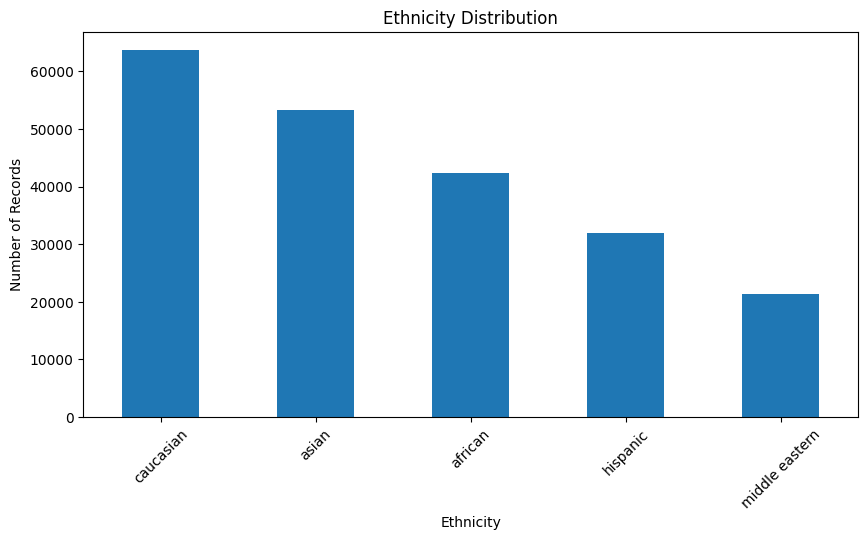

In [20]:
gender_counts = df_copy[GENDER_COL].value_counts().sort_index()

age_group_order = [group_info["label"] for group_info in AGE_GROUPS.values()]
age_group_counts = df_copy["Age_Group"].value_counts().reindex(age_group_order, fill_value=0)

ethnicity_counts = df_copy[ETHNICITY_COL].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
gender_counts.plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10, 5))
age_group_counts.plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
ethnicity_counts.plot(kind="bar")
plt.title("Ethnicity Distribution")
plt.xlabel("Ethnicity")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

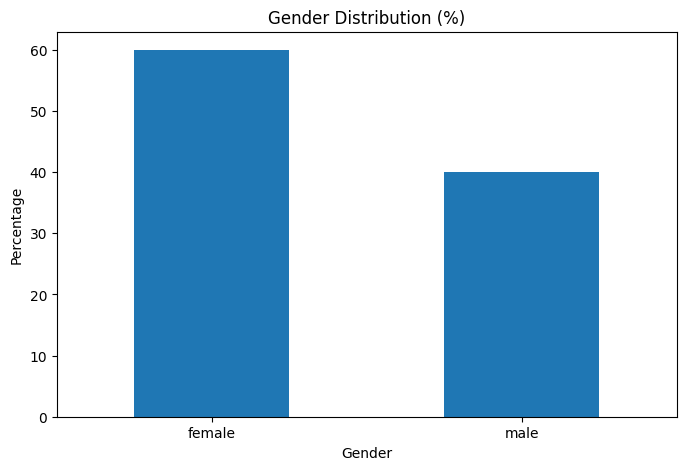

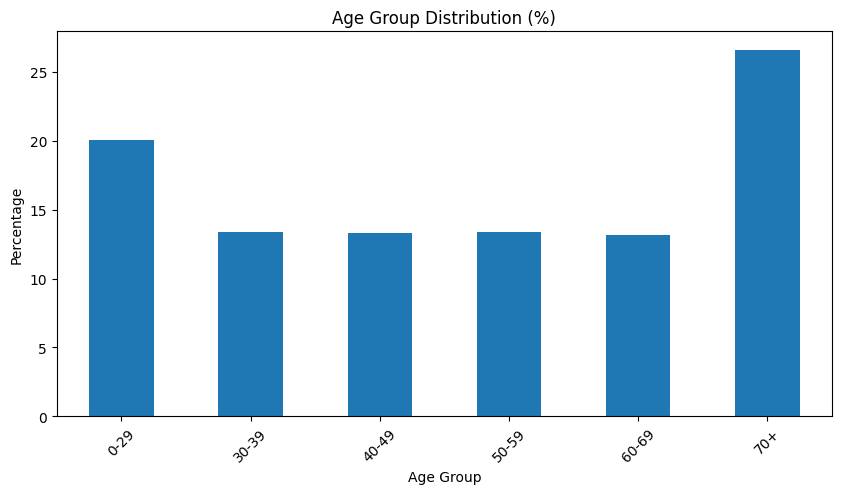

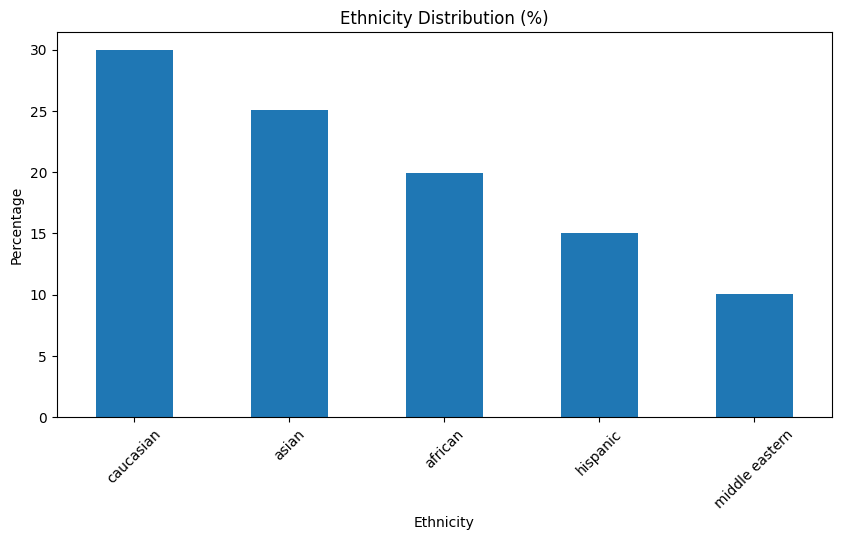

In [18]:
gender_percentages = df_copy[GENDER_COL].value_counts(normalize=True) * 100
age_group_percentages = df_copy["Age_Group"].value_counts(normalize=True).reindex(age_group_order, fill_value=0) * 100
ethnicity_percentages = df_copy[ETHNICITY_COL].value_counts(normalize=True).sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
gender_percentages.plot(kind="bar")
plt.title("Gender Distribution (%)")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10, 5))
age_group_percentages.plot(kind="bar")
plt.title("Age Group Distribution (%)")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 5))
ethnicity_percentages.plot(kind="bar")
plt.title("Ethnicity Distribution (%)")
plt.xlabel("Ethnicity")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [10]:
%load_ext tensorboard

In [11]:
log_dir = os.path.join(
    "/workspace/ethics_of_ai/logs/fit",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

os.makedirs(log_dir, exist_ok=True)
print(log_dir)

/workspace/ethics_of_ai/logs/fit/20260415-115816


In [12]:
writer = tf.summary.create_file_writer(log_dir)

with writer.as_default():
    for step in range(5):
        tf.summary.scalar("test_metric", step * 0.1, step=step)

print("Test TensorBoard logs written.")

W0000 00:00:1776254297.398227 2338583 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1776254297.401291 2338583 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776254297.728689 2338583 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9130 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:0c:00.0, compute capability: 12.0a


Test TensorBoard logs written.


In [13]:
%tensorboard --logdir /workspace/ethics_of_ai/logs/fit

Reusing TensorBoard on port 6006 (pid 628), started 10 days, 15:16:23 ago. (Use '!kill 628' to kill it.)

In [14]:
from witwidget.notebook.visualization import WitWidget, WitConfigBuilder

print("What-If Tool imported successfully.")

TypeError: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates